In [3]:
import pandas as pd
import seaborn as sns
from math import pi

df = pd.read_csv(r'C:\Users\ASUS\Downloads\ipl-data\ipl_match_1473461_deliveries.csv')
df_copy =df.copy()
df


,team,over,batter,bowler,non_striker,runs_batter,runs_extras,runs_total,extras_type,wicket_kind,player_out,fielders
0,Royal Challengers Bengaluru,0,PD Salt,MA Starc,V Kohli,0,0,0,NaN,NaN,NaN,NaN
1,Royal Challengers Bengaluru,0,PD Salt,MA Starc,V Kohli,0,0,0,NaN,NaN,NaN,NaN
2,Royal Challengers Bengaluru,0,PD Salt,MA Starc,V Kohli,0,5,5,wides,NaN,NaN,NaN
3,Royal Challengers Bengaluru,0,PD Salt,MA Starc,V Kohli,1,0,1,NaN,NaN,NaN,NaN
4,Royal Challengers Bengaluru,0,V Kohli,MA Starc,PD Salt,1,0,1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
231,Delhi Capitals,17,T Stubbs,Yash Dayal,KL Rahul,1,0,1,NaN,NaN,NaN,NaN
232,Delhi Capitals,17,KL Rahul,Yash Dayal,T Stubbs,6,0,6,NaN,NaN,NaN,NaN
233,Delhi Capitals,17,KL Rahul,Yash Dayal,T Stubbs,4,0,4,NaN,NaN,NaN,NaN
234,Delhi Capitals,17,KL Rahul,Yash Dayal,T Stubbs,0,5,5,wides,NaN,NaN,NaN


In [4]:
def get_phase(over):
    if over < 6:
        return 'Powerplay'
    elif 6 <= over <15:
        return 'Middle Overs'
    else:
        return 'Death Overs'
df_copy['phase'] = df_copy['over'].apply(get_phase)    

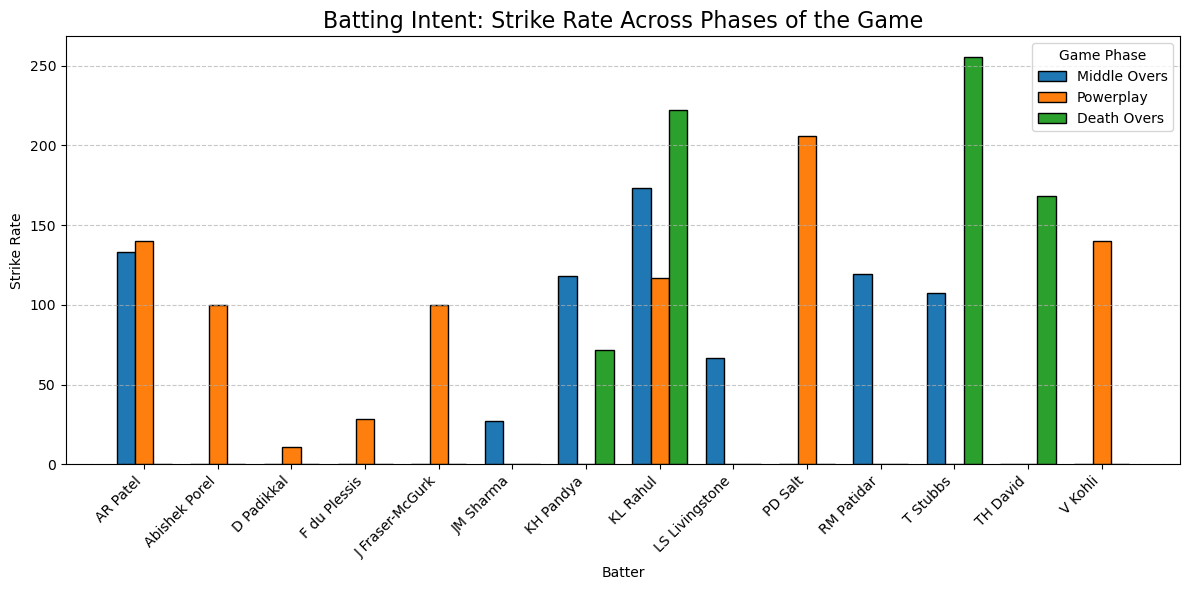

In [5]:
import matplotlib.pyplot as plt
import numpy as np

batting_intent =(df_copy.groupby(['batter','phase']).agg(balls_faced=('runs_batter','count'),
                                                        total_runs=('runs_batter','sum')).reset_index())
batting_intent['strike_rate'] = (batting_intent['total_runs']/batting_intent['balls_faced'])*100
batting_intent=batting_intent[batting_intent['balls_faced']>=5]
batting_intent.sort_values(by=['batter','phase'],inplace = True)

batters = batting_intent['batter'].unique()
phases = batting_intent['phase'].unique()

bar_width = 0.25
x= np.arange(len(batters))

plt.figure(figsize=(12,6))

for idx,phase in enumerate(phases):
    phase_data = batting_intent[batting_intent['phase']==phase]
    strike_rates = [phase_data[phase_data['batter']== batter]['strike_rate'].values[0]
                   if batter in phase_data['batter'].values else 0
                   for batter in batters]
    
    plt.bar(x+idx*bar_width,strike_rates,width = bar_width,label =phase,edgecolor='black') 

plt.xticks(x+bar_width*(len(phases)-1)/2,batters,rotation=45,ha='right')
plt.ylabel("Strike Rate")
plt.xlabel("Batter")
plt.title("Batting Intent: Strike Rate Across Phases of the Game", fontsize=16)
plt.legend(title="Game Phase")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

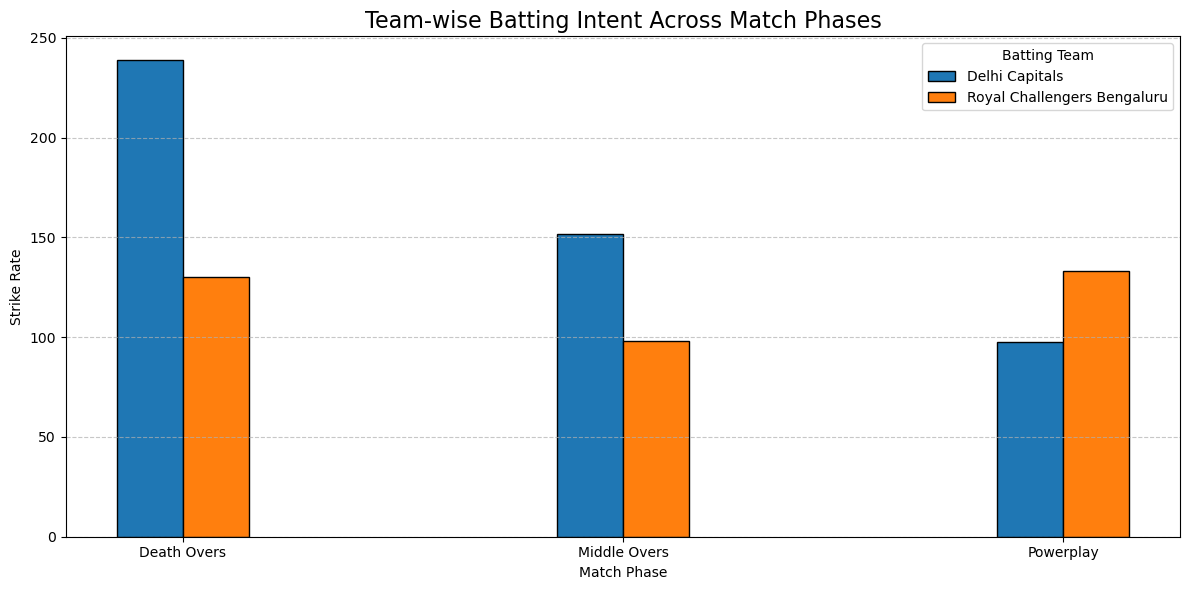

In [6]:
df_copy['batting_team'] = df_copy['team']
team_phase_intent = (df_copy.groupby(['batting_team','phase'])
                     .agg(balls_faced=('runs_batter','count'),
                          total_runs=('runs_batter','sum')).reset_index())
team_phase_intent['strike_rate'] = (team_phase_intent['total_runs']/team_phase_intent['balls_faced'])*100

teams = team_phase_intent['batting_team'].unique()
phases = team_phase_intent['phase'].unique()

bar_width = 0.15
x =np.arange(len(phases))
plt.figure(figsize=(12,6))

for idx, team in enumerate(teams):
    team_data = team_phase_intent[team_phase_intent['batting_team']==team]
    strike_rates = [team_data[team_data['phase']==phase]['strike_rate'].values[0]
                   if phase in team_data['phase'].values else 0
                   for phase in phases]
    plt.bar(x+idx*bar_width,strike_rates,width = bar_width,
           label = team,edgecolor ='black')

plt.xticks(x+bar_width*(len(teams)-1)/2,phases)
plt.xlabel("Match Phase")
plt.ylabel("Strike Rate")
plt.title("Team-wise Batting Intent Across Match Phases", fontsize=16)
plt.legend(title="Batting Team")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

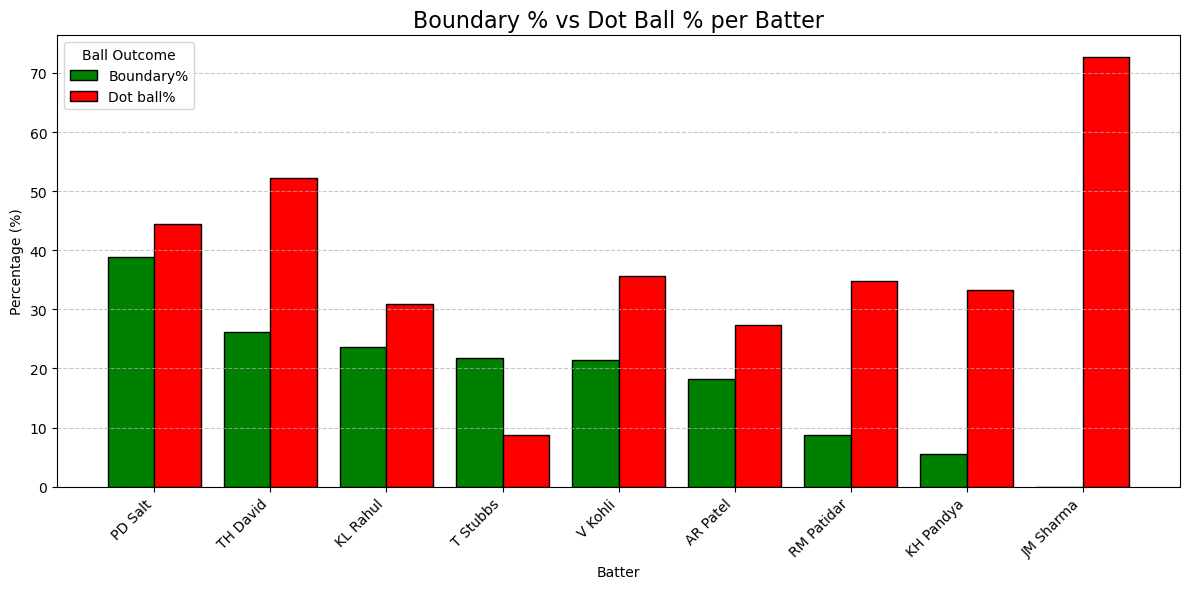

In [7]:
df_copy['ball_outcome'] = df_copy['runs_batter'].apply(
lambda x:'Dot' if x==0 else('Boundary' if x>=4 else 'Run') )

batter_outcome_stats = (df_copy.groupby('batter').ball_outcome.value_counts(normalize=True)
                       .unstack().fillna(0)*100).reset_index()

balls_faced = df_copy.groupby('batter').size().reset_index(name='balls_faced')
batter_outcome_stats =batter_outcome_stats.merge(balls_faced,on='batter')
batter_outcome_stats =batter_outcome_stats[batter_outcome_stats['balls_faced']>=10]

batter_outcome_stats = batter_outcome_stats.sort_values(by='Boundary',ascending = False)

batters = batter_outcome_stats['batter']
boundary_perc = batter_outcome_stats['Boundary']
dot_perc =batter_outcome_stats['Dot']

bar_width = 0.4
x = np.arange(len(batters))

plt.figure(figsize=(12,6))
plt.bar(x-bar_width/2,boundary_perc,width =bar_width,color='green',edgecolor='black',label='Boundary%')
plt.bar(x+bar_width/2,dot_perc,width =bar_width,color='red',edgecolor='black',label='Dot ball%')

plt.xticks(x, batters, rotation=45, ha='right')
plt.ylabel("Percentage (%)")
plt.xlabel("Batter")
plt.title("Boundary % vs Dot Ball % per Batter", fontsize=16)
plt.legend(title="Ball Outcome")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


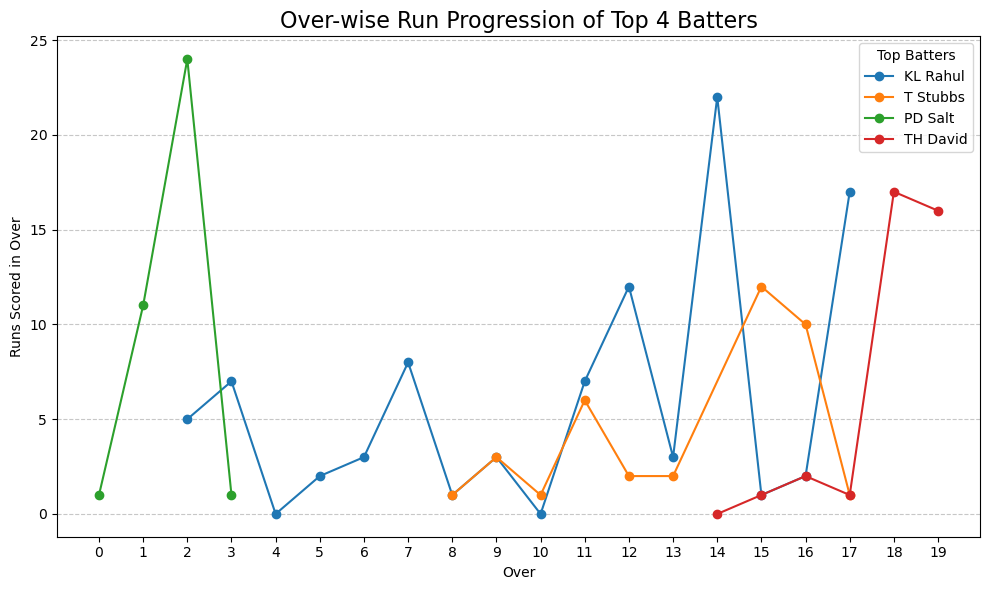

In [8]:
top_batters=(df_copy.groupby('batter')['runs_batter'].sum()
            .sort_values(ascending = False).head(4).index.tolist())
batters_progression =df_copy[df_copy['batter'].isin(top_batters)]
batters_overwise = (batters_progression.groupby(['batter','over'])
                   .agg(runs_in_over=('runs_batter','sum')).reset_index())

plt.figure(figsize=(10,6))

for batter in top_batters:
    batter_data = batters_overwise[batters_overwise['batter']==batter]
    plt.plot(batter_data['over'],batter_data['runs_in_over'],marker='o',
            label = batter)
    
plt.xlabel("Over")
plt.ylabel("Runs Scored in Over")
plt.title("Over-wise Run Progression of Top 4 Batters", fontsize=16)
plt.xticks(range(batters_overwise['over'].min(), batters_overwise['over'].max() + 1))
plt.legend(title="Top Batters")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

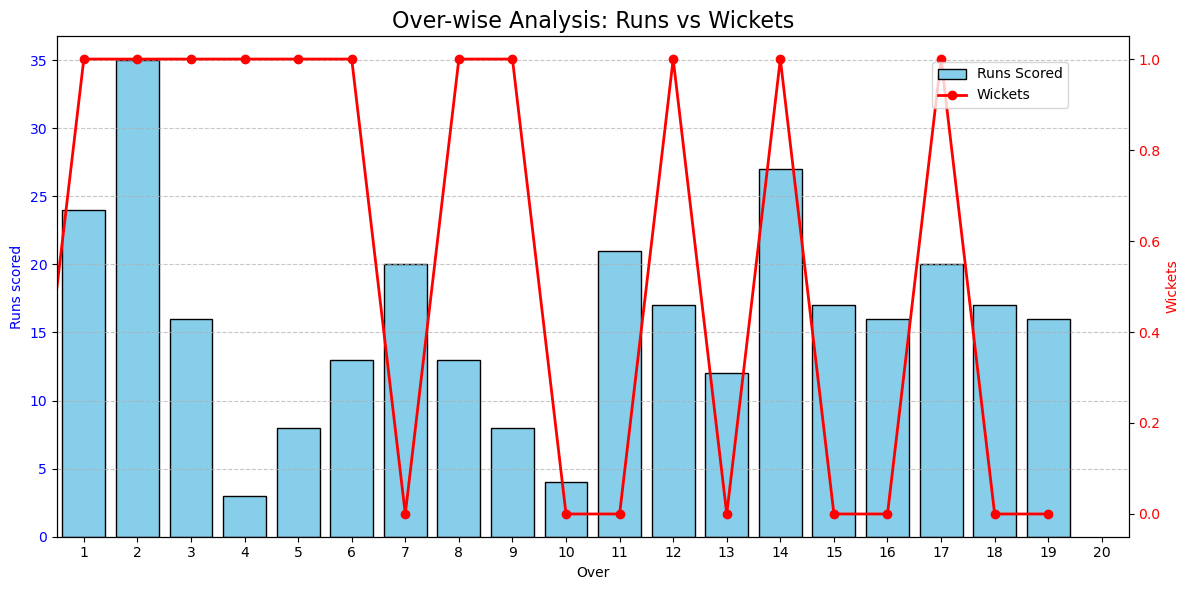

In [9]:
wickets_df = df_copy[df_copy['player_out'].notna()]
wickets_by_over = wickets_df.groupby('over').size().reset_index(name='wickets')
runs_by_over = df_copy.groupby('over')['runs_batter'].sum().reset_index(name='total_runs')

overwise_analysis = pd.merge(runs_by_over,wickets_by_over,on='over',how='left').fillna(0)
overwise_analysis = overwise_analysis.sort_values('over')

fig,ax1 = plt.subplots(figsize=(12,6))

ax1.bar(overwise_analysis['over'],overwise_analysis['total_runs'],
       color='skyblue',edgecolor ='black',label ='Runs Scored')
ax1.set_xlabel('Over')
ax1.set_ylabel("Runs scored",color='blue')
ax1.tick_params(axis='y',labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(overwise_analysis['over'],overwise_analysis['wickets'],
        color ='red',marker='o',linewidth =2, label ='Wickets')
ax2.set_ylabel("Wickets",color='red')
ax2.tick_params(axis='y',labelcolor='red')

ax1.set_xticks(range(1,21))
ax1.set_xlim(0.5,20.5)

plt.title("Over-wise Analysis: Runs vs Wickets",fontsize=16)
ax1.grid(axis='y',linestyle='--',alpha =0.7)
fig.legend(loc='upper right',bbox_to_anchor=(0.9,0.9))
plt.tight_layout()
plt.show()


In [11]:
batter_stats = (
    df_copy.groupby('batter')
    .agg(
        balls_faced=('runs_batter', 'count'),
        total_runs=('runs_batter', 'sum'),
        dismissals=('player_out', lambda x: x.notna().sum())
    )
    .reset_index()
)

outcome_counts = df_copy.groupby(['batter', 'ball_outcome']).size().unstack().fillna(0)
outcome_counts['dot_percent'] = (outcome_counts['Dot'] / outcome_counts.sum(axis=1)) * 100
outcome_counts['boundary_percent'] = (outcome_counts['Boundary'] / outcome_counts.sum(axis=1)) * 100
outcome_counts = outcome_counts[['dot_percent', 'boundary_percent']].reset_index()

batter_profiles = pd.merge(batter_stats, outcome_counts, on='batter')
batter_profiles['strike_rate'] = (batter_profiles['total_runs'] / batter_profiles['balls_faced']) * 100
batter_profiles['average'] = batter_profiles.apply(
    lambda row: row['total_runs'] / row['dismissals'] if row['dismissals'] > 0 else float('inf'), axis=1
)
batter_profiles = batter_profiles[batter_profiles['balls_faced'] >= 10]

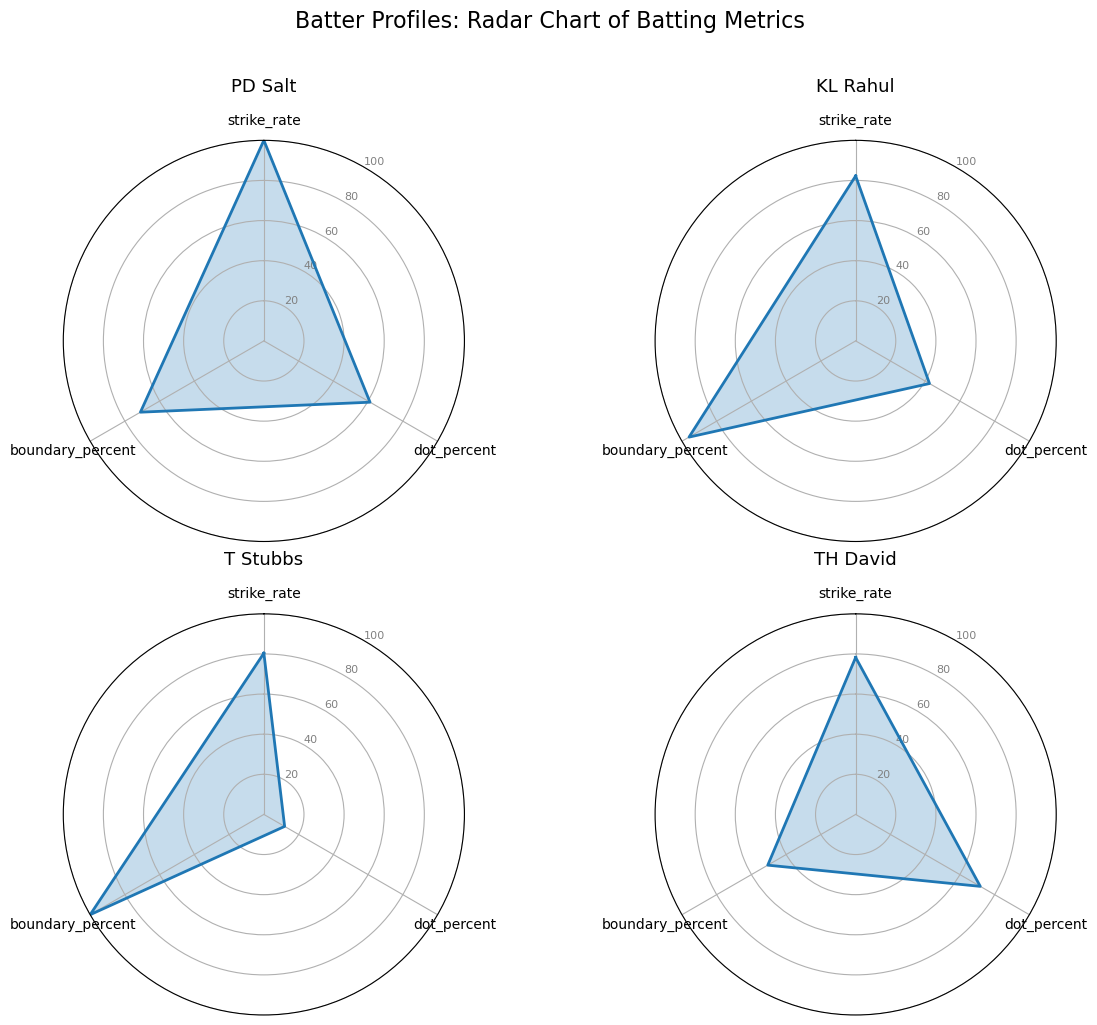

In [16]:
from math import pi, ceil

metrics = ['strike_rate', 'dot_percent', 'boundary_percent']
top_batters_radar = batter_profiles.sort_values(by='strike_rate', ascending=False).head(4).copy()

normalized_profiles = top_batters_radar[['batter'] + metrics].copy()
for metric in metrics:
    max_val = batter_profiles[metric].max()
    normalized_profiles[metric] = (normalized_profiles[metric] / max_val) * 100

num_batters = len(normalized_profiles)
rows = ceil(num_batters / 2)
cols = 2 if num_batters > 1 else 1

angles = [n / float(len(metrics)) * 2 * pi for n in range(len(metrics))]
angles += angles[:1]

fig, axes = plt.subplots(rows, cols, subplot_kw=dict(polar=True), figsize=(12, 5 * rows))
axes = np.array(axes).reshape(-1)  

for plot_idx, (_, row) in enumerate(normalized_profiles.iterrows()):
    values = row[metrics].tolist()
    values += values[:1]  # close loop
    
    ax = axes[plot_idx]
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)
    
    ax.set_rlabel_position(30)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(["20", "40", "60", "80", "100"], color="grey", size=8)
    ax.set_ylim(0, 100)
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['batter'])
    ax.fill(angles, values, alpha=0.25)
    ax.set_title(row['batter'], size=13, y=1.1)

plt.suptitle("Batter Profiles: Radar Chart of Batting Metrics", size=16, y=1.02)
plt.tight_layout()
plt.show()
